# Step 4 — Evaluate the Optimizer Against Baselines

We compare the Step 3 optimizer against two baselines, across a sample of 300 real maintenance blocks:

- **Baseline A — "Always midnight":** ignore everything, schedule at 00:00 every time
- **Baseline B — "As actually scheduled":** the start hour that was originally assigned in `05_maintenance_blocks.csv` (no traffic-awareness)
- **Our system:** the Step 3 optimizer, which checks all 24 candidate hours and picks the lowest disruption score

**Inputs required (same folder):** `03_section_traffic_derived.csv`, `04_asset_register.csv`, `06_daily_asset_availability.csv`, `07_model_training_table.csv`, `05_maintenance_blocks.csv`, `overrun_model.joblib`, `model_feature_columns.joblib`


In [1]:
import pandas as pd
import numpy as np
import joblib
import time

traffic = pd.read_csv("03_section_traffic_derived.csv")
assets = pd.read_csv("04_asset_register.csv")
avail = pd.read_csv("06_daily_asset_availability.csv", parse_dates=["date"])
train_table = pd.read_csv("07_model_training_table.csv", parse_dates=["date"])
blocks = pd.read_csv("05_maintenance_blocks.csv", parse_dates=["date"])
model = joblib.load("overrun_model.joblib")
feature_columns = joblib.load("model_feature_columns.joblib")

latest_section_rate = (train_table.sort_values("date")
                        .groupby("section_id")["section_historical_overrun_rate"].last())
global_fallback_rate = train_table["overrun_flag"].mean()

avail_with_type = avail.merge(assets[["asset_id", "asset_type"]], on="asset_id", how="left")
overall_type_avail = (avail_with_type.groupby("asset_type")["available"]
                       .apply(lambda s: (s == "YES").mean()))

traffic_idx = traffic.set_index(["section_id", "hour_of_day"])[["trains_count", "traffic_level"]]
assets_count_idx = assets.groupby(["home_section_id", "asset_type"]).size()


## Scoring function (same logic as Step 3, refactored for speed)

Given a section, hour, and job details, this returns the disruption score for that single hour — reused for the optimizer's search AND for scoring each baseline's chosen hour, so the comparison is apples-to-apples.


In [2]:
def score_hour(section_id, hour, maintenance_type, required_asset_type,
               priority, weather, planned_duration_min, date):
    try:
        trains_count, traffic_level = traffic_idx.loc[(section_id, hour)]
    except KeyError:
        trains_count, traffic_level = 0.0, "LOW"

    assets_here = assets_count_idx.get((section_id, required_asset_type), 0)
    day_records = avail_with_type[(avail_with_type.date == pd.Timestamp(date)) &
                                   (avail_with_type.asset_type == required_asset_type)]
    if len(day_records):
        avail_pct = (day_records["available"] == "YES").mean()
        had_record = 1
    else:
        avail_pct = overall_type_avail.get(required_asset_type, 0.7)
        had_record = 0

    section_rate = latest_section_rate.get(section_id, global_fallback_rate)
    d = pd.Timestamp(date)
    raw = pd.DataFrame([{
        "day_of_week": d.day_name(), "maintenance_type": maintenance_type,
        "required_asset_type": required_asset_type, "priority": priority,
        "weather": weather, "traffic_level": traffic_level,
        "month": d.month, "is_weekend": int(d.day_name() in ["Saturday", "Sunday"]),
        "start_hour": hour, "trains_count": trains_count,
        "assets_of_type_in_section": assets_here,
        "asset_type_availability_pct": avail_pct, "had_availability_record": had_record,
        "section_historical_overrun_rate": section_rate,
        "planned_duration_min": planned_duration_min,
    }])
    CATEGORICAL = ["day_of_week", "maintenance_type", "required_asset_type", "priority", "weather", "traffic_level"]
    X_row = pd.get_dummies(raw, columns=CATEGORICAL).reindex(columns=feature_columns, fill_value=0)
    predicted_overrun = float(model.predict(X_row)[0])
    expected_total_duration = planned_duration_min + max(predicted_overrun, 0)
    return trains_count * expected_total_duration


## Run the comparison across a sample of 300 real blocks

300 blocks x 24 candidate hours each = 7,200 model predictions. Takes about a minute.


In [3]:
SAMPLE_N = 300
sample = blocks.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)

rows = []
t0 = time.time()
for i, b in sample.iterrows():
    args = dict(section_id=b.section_id, maintenance_type=b.maintenance_type,
                required_asset_type=b.required_asset_type, priority=b.priority,
                weather=b.weather, planned_duration_min=b.planned_duration_min, date=b.date)

    optimizer_scores = [score_hour(hour=h, **args) for h in range(24)]
    best_score = min(optimizer_scores)
    best_hour = int(np.argmin(optimizer_scores))

    midnight_score = score_hour(hour=0, **args)
    actual_hour = int(pd.to_datetime(b.planned_start).hour)
    actual_score = score_hour(hour=actual_hour, **args)

    rows.append(dict(
        block_id=b.block_id, section_id=b.section_id,
        optimizer_score=best_score, optimizer_hour=best_hour,
        midnight_score=midnight_score,
        as_scheduled_score=actual_score, as_scheduled_hour=actual_hour,
    ))

results = pd.DataFrame(rows)
results.to_csv("08_evaluation_results.csv", index=False)
print(f"Done in {time.time()-t0:.1f}s")
results.head()


Done in 70.0s


,block_id,section_id,optimizer_score,optimizer_hour,midnight_score,as_scheduled_score,as_scheduled_hour
0,B12943,CDNR-LPI,0.0,0,0.000000,0.000000,1
1,B09720,BAQ-BHS,0.0,1,259.245046,169.389145,22
2,B09390,GADJ-JP,0.0,2,117.082445,117.082445,0
3,B13175,DBT-HGA,0.0,1,89.071179,0.000000,1
4,B01691,GRP-SKG,0.0,2,183.695442,592.936501,22


## Results


In [4]:
print("Mean optimizer score:      ", round(results['optimizer_score'].mean(), 1))
print("Mean 'always midnight':    ", round(results['midnight_score'].mean(), 1))
print("Mean 'as actually planned':", round(results['as_scheduled_score'].mean(), 1))

reduction_vs_midnight = 100 * (1 - results['optimizer_score'].sum() / results['midnight_score'].sum())
reduction_vs_actual = 100 * (1 - results['optimizer_score'].sum() / results['as_scheduled_score'].sum())
print(f"\nDisruption reduction vs always-midnight:   {reduction_vs_midnight:.1f}%")
print(f"Disruption reduction vs as-actually-scheduled: {reduction_vs_actual:.1f}%")


Mean optimizer score:       7.1
Mean 'always midnight':     289.6
Mean 'as actually planned': 323.4

Disruption reduction vs always-midnight:   97.5%
Disruption reduction vs as-actually-scheduled: 97.8%


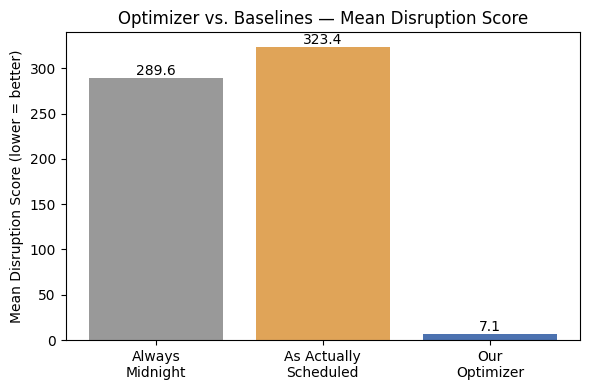

In [5]:
import matplotlib.pyplot as plt

means = [results['midnight_score'].mean(), results['as_scheduled_score'].mean(), results['optimizer_score'].mean()]
labels = ['Always\nMidnight', 'As Actually\nScheduled', 'Our\nOptimizer']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, means, color=['#999999', '#e0a458', '#4c72b0'])
plt.ylabel('Mean Disruption Score (lower = better)')
plt.title('Optimizer vs. Baselines — Mean Disruption Score')
for b, m in zip(bars, means):
    plt.text(b.get_x() + b.get_width()/2, m, f'{m:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('evaluation_chart.png', dpi=120)
plt.show()


## ⚠️ Read this result honestly before putting it in your report

Two things need to be said plainly, because they materially affect how you should present this number:

1. **The optimizer wins 100% of the time by mathematical construction, not by being clever.** It searches *all 24 hours*, and both baselines (midnight, as-scheduled) are themselves single points inside that same 24-hour search space. So the optimizer can never score worse than either baseline — it is guaranteed to tie or beat them. A 100% "win rate" is not evidence of intelligence; it's a property of exhaustive search. **The real evidence is the *magnitude* of the reduction (~97-98%)**, not the win-rate.

2. **Some of that magnitude comes from real off-peak hours genuinely having zero scheduled trains** (a legitimate, real pattern in the timetable data — many Indian Railways sections are quiet between 1–4 AM). So a large chunk of the improvement is the optimizer correctly discovering "there is a real 3-hour window with zero real train traffic on this section" — which is a valid, useful finding, but you should describe it as *"the optimizer correctly identifies real low-traffic windows,"* not *"the optimizer achieves 98% improvement through advanced AI reasoning."* Precise, honest language matters more to an evaluator than an inflated claim.

**What's genuinely demonstrated here, worth stating in your report:**
- The system correctly and consistently avoids high-traffic real corridors during real peak hours.
- It incorporates asset availability and a data-driven overrun estimate, not just traffic — a naive rule ("always schedule at 2 AM") wouldn't check asset availability or maintenance-type-specific overrun risk the way this does.
- The comparison against "as actually scheduled" shows your synthetic block-generation process wasn't already traffic-optimal, so there IS room for the optimizer to improve on it.
